# Surface code with repeated syndrome extraction Circ Level Noise (mulitple rounds)

Data generation and analysis
+ different decoder: MWPM
+ different observables: Z,X
+ different distances
+ different noise levels

analysis: 
+ show asymptotic behavior (not important)
+ determine thresholds


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tools.file import write_config, smart_read_folder
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

## Config Defintions and Data Generation

Steane circ (order 0p) with only 1 QEC round (both log X and Z observable)

Circ noise with different noise levels

Decoding both in ML and MWPM


In [2]:
# General parameter
expected_p_th_log = -2
width = 0.5 
noise_rates = [float(x) for x in np.logspace(expected_p_th_log - width , expected_p_th_log + width,dtype=float)]
distances = [3,5]#9,11] 
qec_rounds = [1,2]
order = "0p"
circuit_type = "surface"
noise_model_type = "circ"

# Main parameters
num_shots_MWPM = 1_000
decoder_type_MWPM = "mwpm_full_info"

# Z config
observable_Z  = "Z"
init_state_Z = "0"
# X config
observable_X  = "X"
init_state_X = "p"

In [ ]:
# Folder names (for writing data to file):
general_name = "md_mr_mp_surface_test"


In [4]:
# Switches for data generation
regen_data_everything = False 

regen_data_MWPM = False 
regen_data_Z = True 


In [5]:
# MWPM Config (Z)

config_MWPM_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,       # number of shots per configuration
    },
}

# write config to file
config_path = write_config(config_MWPM_Z, general_name, backup=True, sub_name="MWPM_Z")

# Generate ML Data
if regen_data_everything or regen_data_MWPM or regen_data_Z or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

starting: d: 1/2, r: 1/2, p: 1/50
done. took: 0:00:00.047029
starting: d: 1/2, r: 1/2, p: 2/50
done. took: 0:00:00.038409
starting: d: 1/2, r: 1/2, p: 3/50
done. took: 0:00:00.031347
starting: d: 1/2, r: 1/2, p: 4/50
done. took: 0:00:00.029912
starting: d: 1/2, r: 1/2, p: 5/50
done. took: 0:00:00.030231
starting: d: 1/2, r: 1/2, p: 6/50
done. took: 0:00:00.030402
starting: d: 1/2, r: 1/2, p: 7/50
done. took: 0:00:00.032817
starting: d: 1/2, r: 1/2, p: 8/50
done. took: 0:00:00.031330
starting: d: 1/2, r: 1/2, p: 9/50
done. took: 0:00:00.030679
starting: d: 1/2, r: 1/2, p: 10/50
done. took: 0:00:00.030665
starting: d: 1/2, r: 1/2, p: 11/50
done. took: 0:00:00.030742
starting: d: 1/2, r: 1/2, p: 12/50
done. took: 0:00:00.030794
starting: d: 1/2, r: 1/2, p: 13/50
done. took: 0:00:00.031740
starting: d: 1/2, r: 1/2, p: 14/50
done. took: 0:00:00.032887
starting: d: 1/2, r: 1/2, p: 15/50
done. took: 0:00:00.031718
starting: d: 1/2, r: 1/2, p: 16/50
done. took: 0:00:00.031366
starting: d: 1/2,

In [6]:
# MWPM Config (X)

config_MWPM_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,     
    },
}

# write config to file
config_path = write_config(config_MWPM_X, general_name, backup=True, sub_name="MWPM_X")

# Generate ML Data
if regen_data_everything or regen_data_MWPM or False  :
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

# Analysis

In [12]:
# Folder paths (reading in data)
# r_folder_path_MWPM_Z = "/home/fu494742/MasterArbeit/code/data/surface/0p/circ/mwpm/z/md_1r_mp_surface_test"
# r_folder_path_MWPM_X = "/home/fu494742/MasterArbeit/code/data/surface/0p/circ/mwpm/x/md_1r_mp_surface_test"

r_folder_path_MWPM_Z = "/home/leo/Documents/MasterArbeit/code/data/surface/0p/circ/mwpm/z/md_mr_mp_surface_test"
r_folder_path_MWPM_X = "/home/leo/Documents/MasterArbeit/code/data/surface/0p/circ/mwpm/x/md_mr_mp_surface_test"

# basic
# r_folder_path_MWPM_Z = "/home/leo/Documents/MasterArbeit/code/data/surface/0p/basic/mwpm/z/md_mr_mp_surface_test"

# last faultless
# r_folder_path_MWPM_Z = "/home/leo/Documents/MasterArbeit/code/data/surface/0p/circ/mwpm/z/md_mr_mp_surface_test_last_faultless"

# full info
r_folder_path_MWPM_Z = "/home/leo/Documents/MasterArbeit/code/data/surface/0p/circ/mwpm_full_info/z/md_mr_mp_surface_test"


# basic noise
# r_folder_path_MWPM_Z = "/home/fu494742/MasterArbeit/code/data/surface/0p/basic/mwpm/z/md_1r_mp_surface_test"

In [13]:
def analysis_pipeline(
        folder_path, 
        guess_pth, 
        guess_nu, 
        min_distance: list = None, 
        max_distance: list = None,
        min_noise_rate: list = None,
        max_noise_rate: list = None,
        p_window: list = None,
        plots = True,
        ):

    if p_window != None:
        if min_noise_rate != None or max_noise_rate != None:
            raise UserWarning("Both p_window and min-/max_noise_rate give! Too much restictions!")
        min_noise_rate = np.array(guess_pth) / p_window
        max_noise_rate = np.array(guess_pth) * p_window

    config, data = smart_read_folder(folder_path=folder_path)
    data = data_pre_processing(data)
    # data = determine_threshold(
    #     data,
    #     guess_nu=guess_nu,
    #     guess_pth=guess_pth,
    #     min_distance=min_distance,
    #     max_distance=max_distance,
    #     min_noise_rate=min_noise_rate,
    #     max_noise_rate=max_noise_rate,
    #     )
    # complete
    if plots:
        data_plot_log_error_rates(
            data,
            reference_lines=True,
            )
        # data_plot_fssa_results(
        #     data,
        #     min_distance=min_distance,
        #     max_distance=max_distance,
        #     min_noise_rate=min_noise_rate,
        #     max_noise_rate=max_noise_rate,
        #     )
        # # around threshold
        # data_plot_log_error_rates(
        #     data,
        #     min_distance=min_distance,
        #     max_distance=max_distance,
        #     min_noise_rate=min_noise_rate,
        #     max_noise_rate=max_noise_rate,
        # )
    return data

### Generate analysis Data

In [14]:
# General fit parameters: 
g_pth_mwpm_Z = [0.027]
g_pth_mwpm_X = [0.035]

g_nu = [1.5]

p_window = [10**(0.1)]
min_distance = [7]

<Figure size 640x480 with 0 Axes>

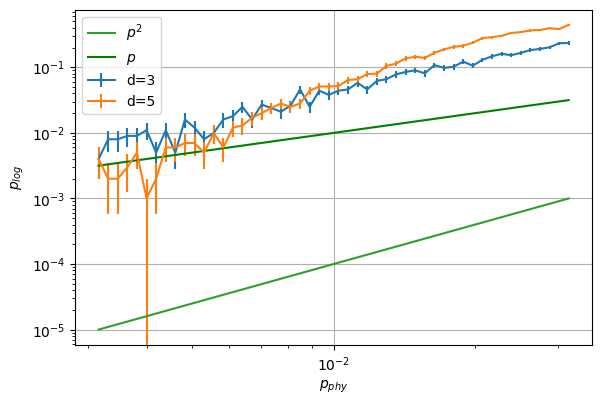

<Figure size 640x480 with 0 Axes>

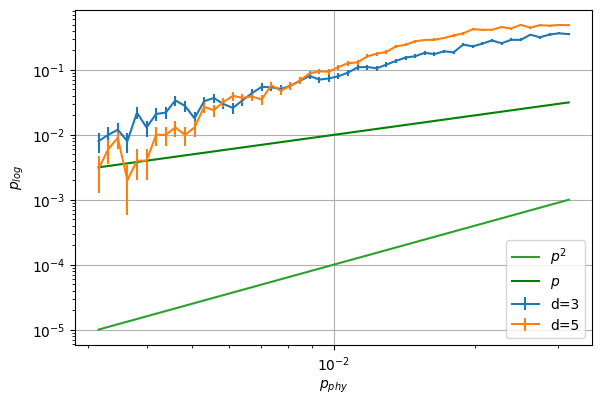

In [15]:
folder_path = r_folder_path_MWPM_Z 
g_pth = g_pth_mwpm_Z

result = analysis_pipeline(
    folder_path = folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window =  p_window,
    )

# print(result["p_th"])
# print(result["nu_fit"])
results_MWPM_Z= result

In [11]:
folder_path = r_folder_path_MWPM_X 
g_pth = g_pth_mwpm_X 

result = analysis_pipeline(
    folder_path = folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window =  p_window,
    )

# print(result["p_th"])
# print(result["nu_fit"])
results_MWPM_X = result

FileNotFoundError: [Errno 2] No such file or directory: '/home/leo/Documents/MasterArbeit/code/data/surface/0p/circ/mwpm/x/md_mr_mp_surface_test/config.yaml'

In [ ]:
results = [results_MWPM_Z, results_MWPM_X]
names = ["MWPM Z", "MWPM X"]
for i in range(len(results)):
    print(f"{names[i]}: num_shots = {results[i]["num_shots"]/10**3}k")

MWPM Z: num_shots = 1.0k
MWPM X: num_shots = 1.0k


## Thresholds Results (1 round circ noise)

In [ ]:
# collection of all threshold:
results = [results_MWPM_Z, results_MWPM_X]
names = ["MWPM Z", "MWPM X"]

for i in range(len(names)):
    print(f"For {names[i]}: threshold = {results[i]["p_th"][0]*10**2:.3f} +- {results[i]["err_p_th"][0]*10**2:.3f}") 



KeyError: 'p_th'